# Explainable AI using SHAP

Machine Learning models such as XGBoost can achieve high prediction accuracy, but they often behave as black-box models. While they provide predictions, they do not clearly explain why a particular prediction was made.

Explainable Artificial Intelligence (XAI) helps interpret machine learning models by identifying the contribution of each feature to the final prediction.

In this notebook, SHAP (SHapley Additive exPlanations) is used to explain both the overall behavior of the model and the prediction made for individual students.

In [23]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [24]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [25]:
model = joblib.load("student_dropout_xgboost.pkl")

In [26]:
feature_names = joblib.load("feature_names.pkl")

In [27]:
df = pd.read_csv("../data/processed/final_dataset.csv")

In [28]:
X = df.drop("dropout", axis=1)
y = df["dropout"]

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [30]:
X = X.reindex(columns=feature_names, fill_value=0)

In [31]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

In [32]:
import shap
print(shap.__version__)

0.52.0


In [33]:
shap_values.shape

(32548, 76)

In [34]:
print(type(explainer))
print(type(shap_values))

<class 'shap.explainers._tree.TreeExplainer'>
<class 'numpy.ndarray'>


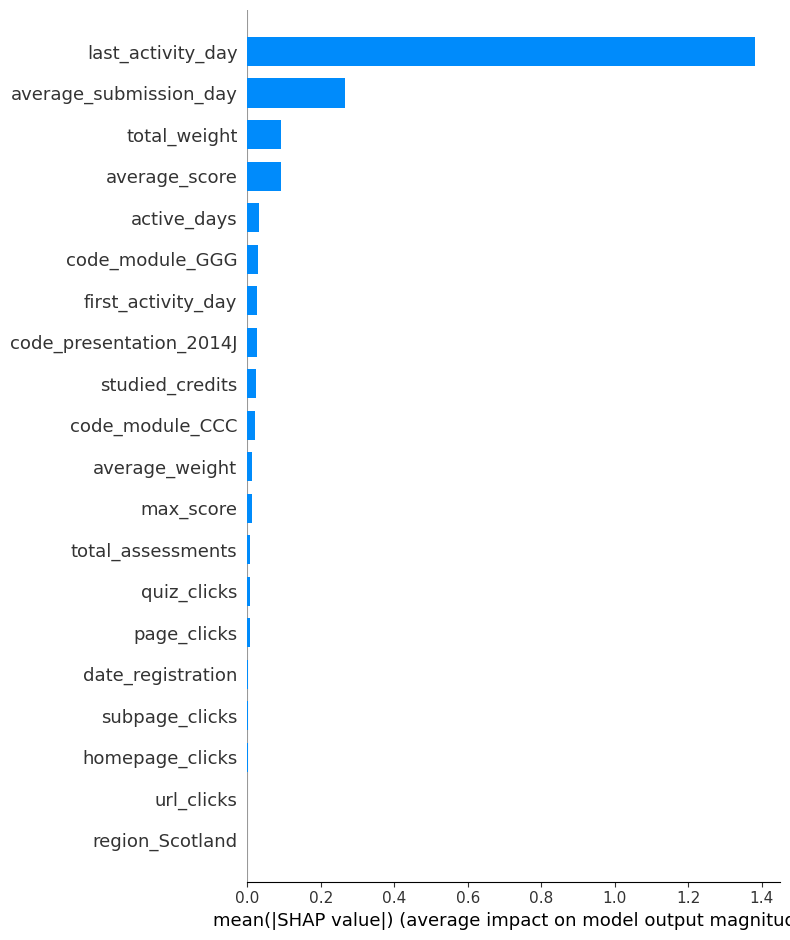

In [35]:
shap.summary_plot(shap_values, X, plot_type="bar", max_display=20)

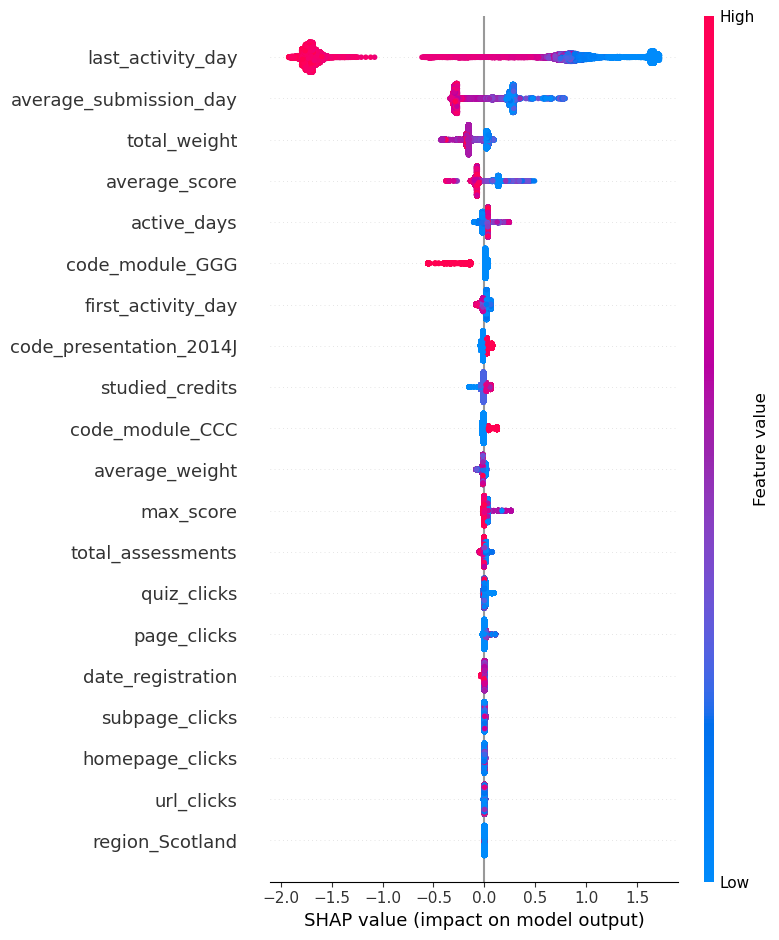

In [36]:
shap.summary_plot(shap_values, X, max_display=20)

Since TreeExplainer returned SHAP values as a NumPy array, the classic SHAP summary plot functions were used for global explainability.

In [37]:
print(explainer.expected_value)

-0.7986522


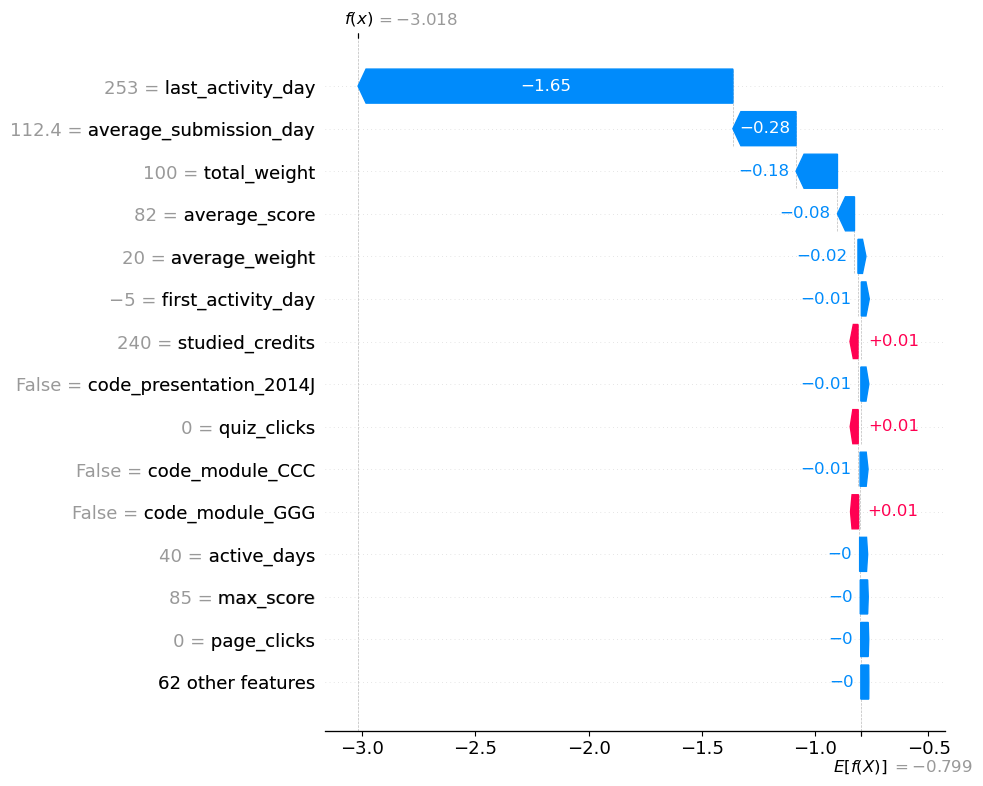

In [38]:
student_index = 0
exp = shap.Explanation(
    values=shap_values[student_index],
    base_values=explainer.expected_value,
    data=X.iloc[student_index],
    feature_names=X.columns
)
shap.plots.waterfall(exp, max_display=15)

In [39]:
predictions = model.predict(X)
import numpy as np
dropout_index = np.where(predictions == 1)[0][0]
print("Student Index:", dropout_index)

Student Index: 2


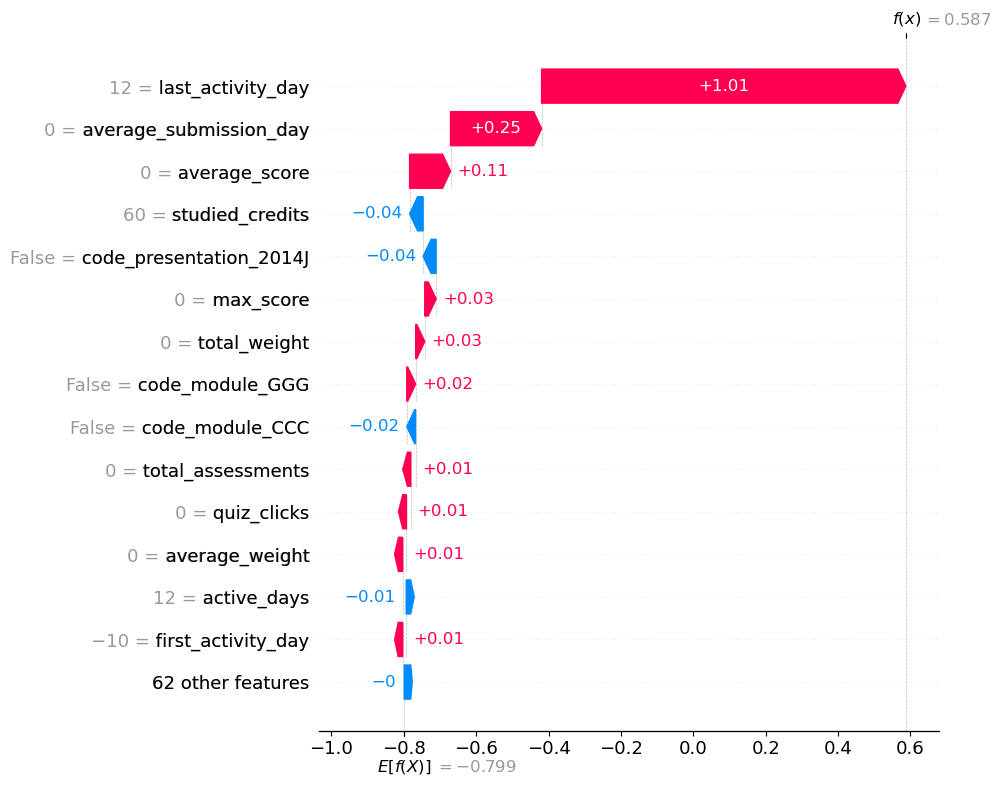

In [40]:
exp = shap.Explanation(
    values=shap_values[dropout_index],
    base_values=explainer.expected_value,
    data=X.iloc[dropout_index],
    feature_names=X.columns
)

shap.plots.waterfall(exp, max_display=15)

In [41]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[dropout_index],
    X.iloc[dropout_index]
)

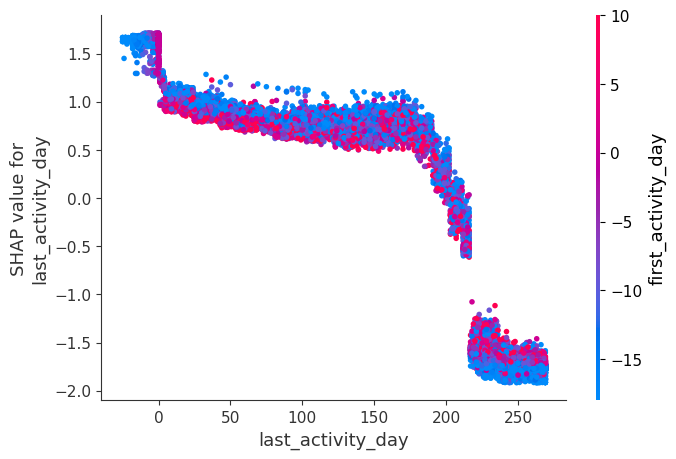

In [42]:
shap.dependence_plot(
    "last_activity_day",
    shap_values,
    X
)

## Business Insights

The SHAP analysis provided valuable insights into the factors influencing student dropout predictions. Beyond achieving good predictive performance, the model also helped explain **why** certain students were identified as being at risk, making the results more transparent and actionable.

One of the most important findings was the impact of **student engagement**. Features related to activity on the Virtual Learning Environment (VLE), particularly the **last activity day**, showed a strong influence on the model's predictions. Students who remained active throughout the course generally had a lower predicted risk of dropping out, while students whose activity stopped early were more likely to be classified as at risk. This suggests that continuous engagement is a strong indicator of student persistence.

Academic performance also played a significant role. Assessment scores, submission behavior, and learning activity contributed noticeably to the predictions. Students with consistently lower assessment performance or reduced participation in course activities tended to receive higher dropout probabilities.

Another interesting observation was the importance of **registration timing**. Although it was not initially expected to be a highly influential feature, the model identified it as an important predictor. This indicates that students who register later may exhibit different learning behaviors or engagement patterns compared to those who register earlier. This observation could be explored further in future research.

From an institutional perspective, these findings have practical value. Instead of waiting until students fail assessments or discontinue their studies, universities can monitor engagement patterns and academic behavior throughout the semester. Students showing early signs of disengagement can be identified and offered timely academic guidance, mentoring, or additional learning support before they are at serious risk of dropping out.

Overall, the combination of XGBoost and SHAP not only produced accurate predictions but also provided meaningful explanations, making the model suitable for supporting data-driven decision-making in educational environments.